In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

# Two-sheet covering

Let's explore the two-sheet covering of the Klein bottle by the torus.

(See the Geogebra `.ggb` file for a visualisation and details)

Following this [question on Math.Stackexchange](https://math.stackexchange.com/questions/1073425/two-sheeted-covering-of-the-klein-bottle-by-the-torus), given a torus as a $[0,1]^2$ square with proper gluing of the sides,
we identify (glue) any two points $A$ and $B$ on a torus with such coordinates:

$A(x,y)\sim B\big(1-x, (y+\frac{1}{2}) \text{ mod } 1\big)$

So one should find such a mapping $f()$ that $f(A)=f(B)$ for any two such points. One such mapping is:

$$f_x(x,y) = \begin{cases}
2x, \text{  if  }0\leq x\leq1/2 \\
2-2x, \text{  if  }1/2< x\leq1
\end{cases} \\
f_y(x,y) = \begin{cases}
2y, \text{  if  }0\leq y\leq1/2 \\
2y-1, \text{  if  }1/2< y\leq1
\end{cases} 
$$

Let's play with it a bit:

In [11]:
def cover(points):
    """
    points is of shape = (n_points, 2)
    """
    xs, ys = points[:,0], points[:,1]
    xs_K, ys_K = [], []
    for i in range(points.shape[0]):
        x, y = xs[i], ys[i]
        xs_K.append(2*x if x <= 0.5 else 2-2*x)
        ys_K.append(2*y if y <= 0.5 else 2*y-1)
    return np.array([xs_K,ys_K]).T

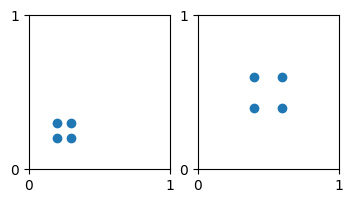

In [15]:
fig = plt.figure(figsize=(4,2))
ax = fig.subplots(1,2)

for i in [0,1]:
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].axes.get_xaxis().set_ticks([0,1])
    ax[i].axes.get_yaxis().set_ticks([0,1])

    
points = np.array([[0.2,0.2],
         [0.3,0.2],
         [0.2,0.3],
         [0.3,0.3]])


ax[0].scatter(points[:,0],points[:,1])

covers = cover(points)

ax[1].scatter(covers[:,0],covers[:,1])

In [16]:
x1 = np.random.multivariate_normal(mean=np.array([0.5,0.5]), 
                                   cov=np.array([[1,0],[0,1]]),
                                  size=100)

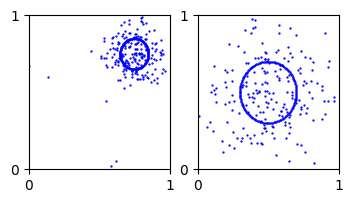

In [23]:
fig = plt.figure(figsize=(4,2))
ax = fig.subplots(1,2)

for i in [0,1]:
    ax[i].set_xlim(0,1)
    ax[i].set_ylim(0,1)
    ax[i].axes.get_xaxis().set_ticks([0,1])
    ax[i].axes.get_yaxis().set_ticks([0,1])

    
points = np.random.multivariate_normal(mean=np.array([0.75,0.75]), 
                                   cov=np.array([[0.01,0],[0,0.01]]),
                                  size=200)

points = points % 1


angles = np.linspace(0,2*np.pi,200)
circle = np.array([np.cos(angles), np.sin(angles)]).T * 0.1
circle += 0.75

ax[0].scatter(points[:,0],points[:,1],s=0.4,color='blue')
ax[0].scatter(circle[:,0],circle[:,1],s=0.3,color='blue')

covers = cover(points)

c_circle = cover(circle)

ax[1].scatter(covers[:,0],covers[:,1],s=0.4,color='blue')
ax[1].scatter(c_circle[:,0],c_circle[:,1],s=0.3,color='blue')

In [51]:
circle

array([[0.6       , 0.59979867, 0.59919548, 0.59819287, 0.59679487,
        0.59500711, 0.59283679, 0.59029265, 0.58738494, 0.58412535,
        0.58052703, 0.57660444, 0.5723734 , 0.56785094, 0.56305527,
        0.55800569, 0.55272255, 0.54722711, 0.5415415 , 0.53568862,
        0.52969204, 0.52357589, 0.51736482, 0.51108382, 0.50475819,
        0.4984134 , 0.492075  , 0.48576852, 0.47951933, 0.47335262,
        0.4672932 , 0.46136549, 0.45559334, 0.45      , 0.44460799,
        0.43943903, 0.43451393, 0.42985251, 0.42547356, 0.42139469,
        0.41763234, 0.41420166, 0.41111646, 0.40838915, 0.40603074,
        0.4040507 , 0.40245702, 0.40125611, 0.40045281, 0.40005035,
        0.40005035, 0.40045281, 0.40125611, 0.40245702, 0.4040507 ,
        0.40603074, 0.40838915, 0.41111646, 0.41420166, 0.41763234,
        0.42139469, 0.42547356, 0.42985251, 0.43451393, 0.43943903,
        0.44460799, 0.45      , 0.45559334, 0.46136549, 0.4672932 ,
        0.47335262, 0.47951933, 0.48576852, 0.49

# My Covering

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ripser import ripser 
from persim import plot_diagrams

In [3]:
a = 3
b = 4

def double_covering(x, y):
    """
    Applies the double covering map to arrays x and y.
    Supports numpy arrays (and later torch tensors).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    mask = x <= 0.5
    u = np.where(mask, 2 * x, 2 * x - 1)
    v = np.where(mask, y, 1 - y)
    return u, v

#https://www.mathcurve.com/surfaces.gb/klein/klein.shtml
def projection(u,v):
    return (
        (a + b * np.cos(v)) * np.cos(u),
        (a + b * np.cos(v)) * np.sin(u),
        (b * np.sin(v)) * np.cos(u/2),
        (b * np.sin(v)) * np.sin(u/2),
    )

So `double_covering` and `projection` returns a point in $\R^4$ on the surface of Klein bottle. Now if we are able to sample a point from a torus, we can therefore do what we need.

Check https://mathoverflow.net/a/484137/130473 for tests

In [4]:
random_x = np.random.normal(0, 1, (1,))
random_y = np.random.normal(0, 1, (1,))

u,v=double_covering(random_x, random_y)
x,y,z,t = projection(u,v)

In [5]:
assert np.isclose(4*a**2*(x**2 + y**2), (a**2 - b**2 + x**2 + y**2 + z**2 + t**2)**2)
assert np.isclose(y * (z**2 - t**2), 2 * x * z * t)
assert x * (z**2 - t**2) >= 0
assert y * z * t >= 0

In [6]:
num_points = 1_000
random_xs = np.random.normal(0, 1, (num_points,))
random_ys = np.random.normal(0, 1, (num_points,))

us, vs = double_covering(random_xs, random_ys)
xs, ys, zs, ts = projection(us, vs)
points = np.stack([xs, ys, zs, ts], axis=1)

points.shape

(1000, 4)

In [ ]:
%%time

diagrams2 = ripser(points, coeff=2, maxdim=2)['dgms']
diagrams3 = ripser(points, coeff=3, maxdim=2)['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title('Z_2')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('Z_3')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

: 

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_37750/3935299713.py:3: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title('$\mathbb{Z}_2$')
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_37750/3935299713.py:6: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('$\mathbb{Z}_3$')


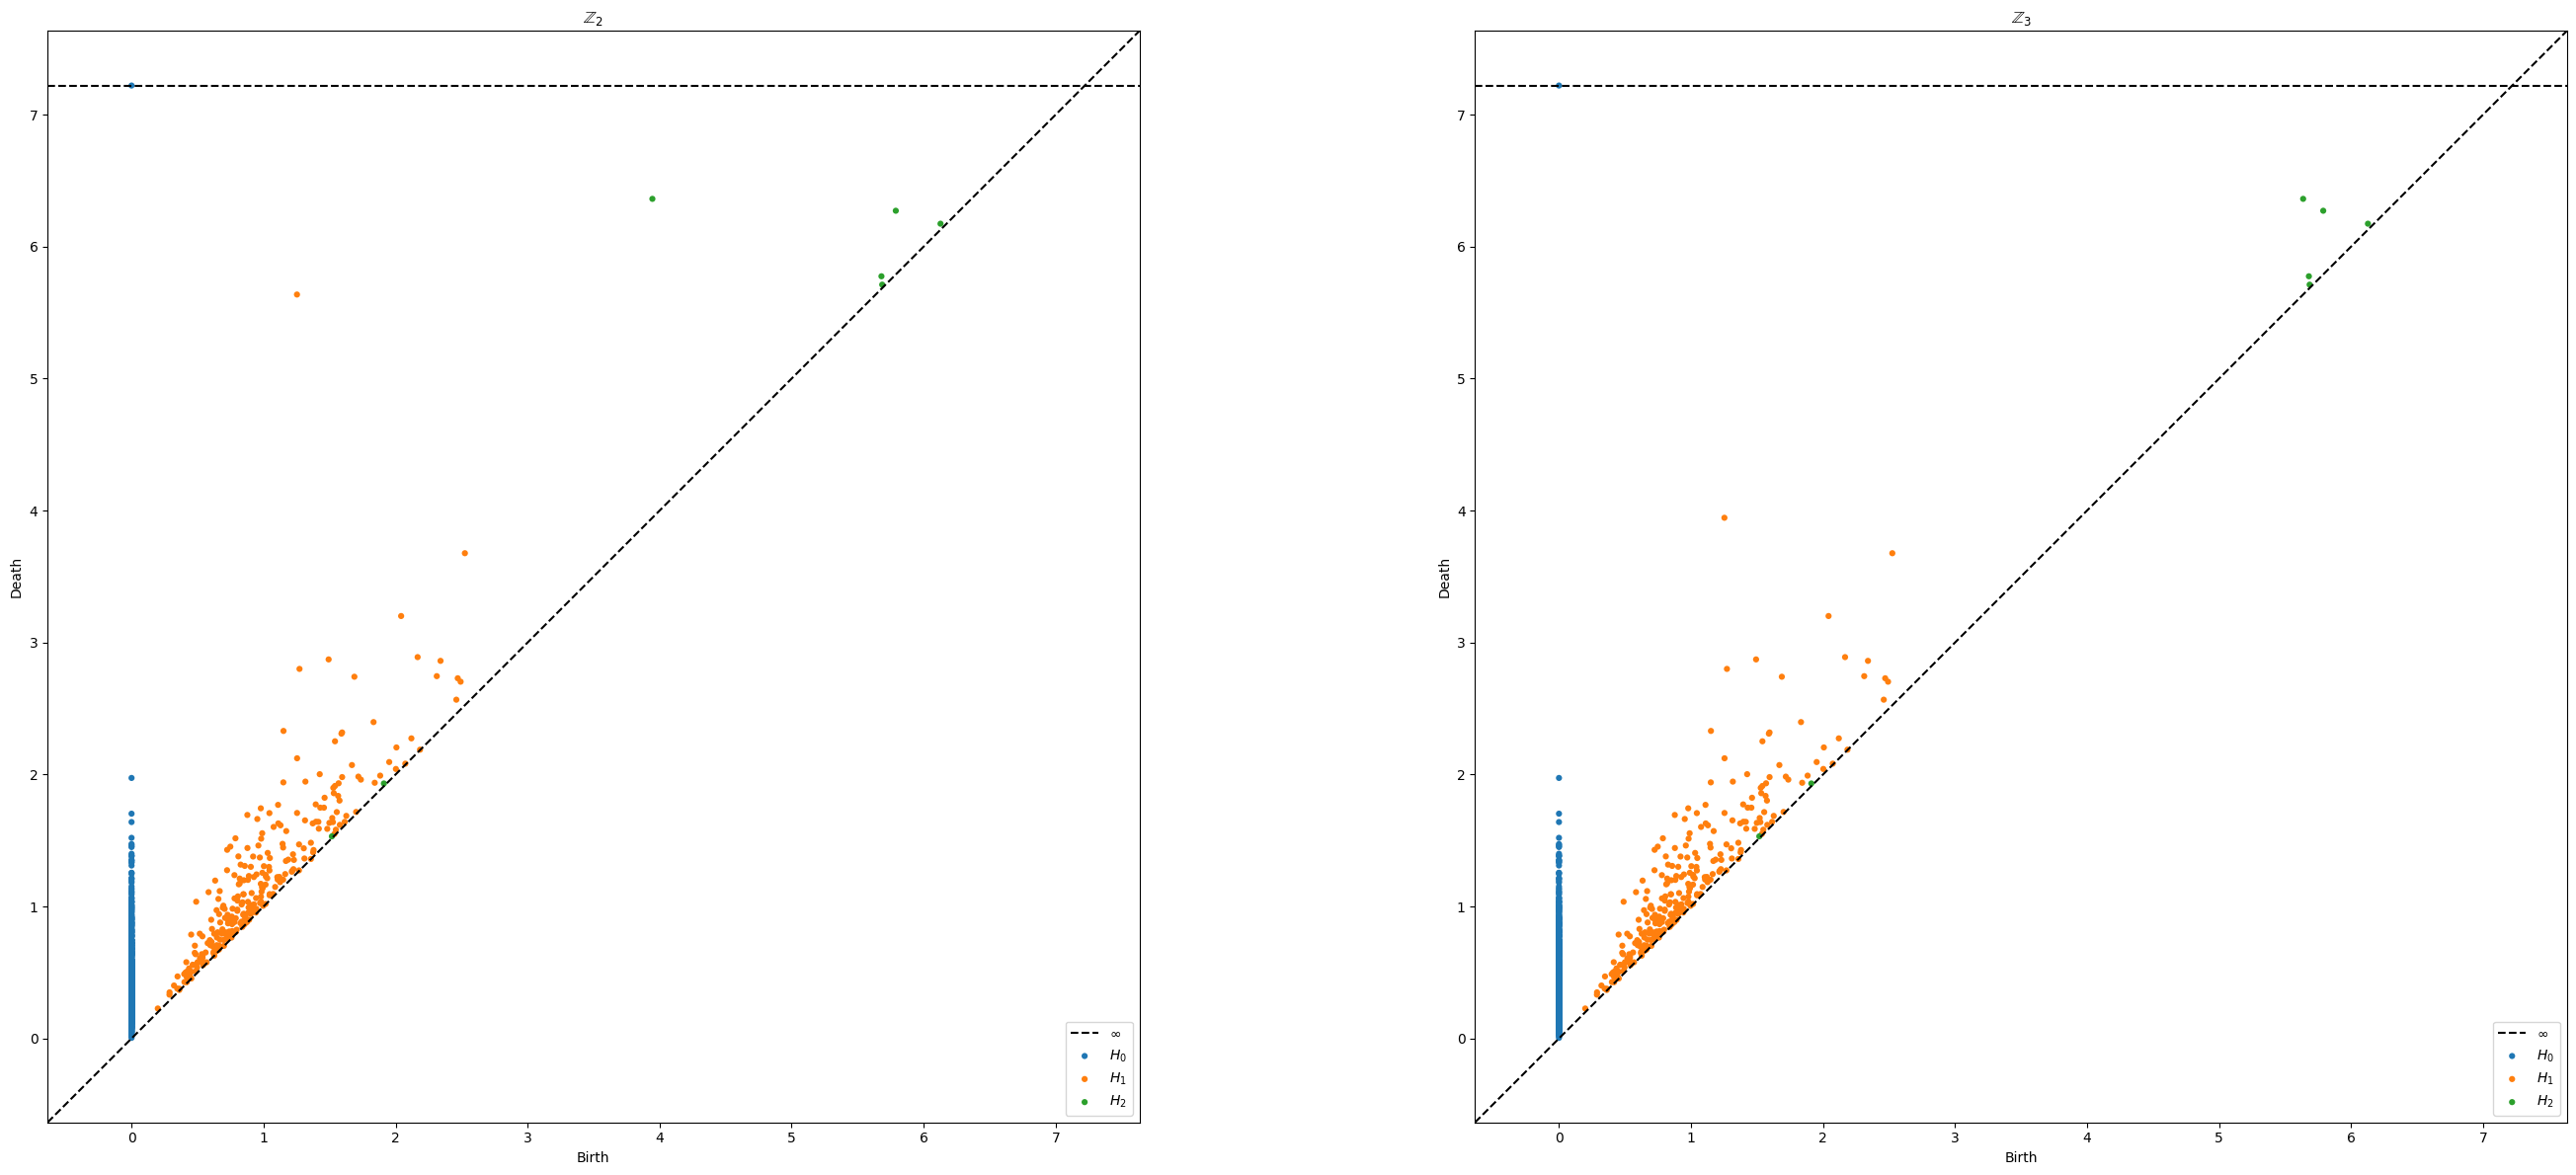

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(30, 12))

axes[0].set_title('$\mathbb{Z}_2$')
plot_diagrams(diagrams2, ax=axes[0], show=False)

axes[1].set_title('$\mathbb{Z}_3$')
plot_diagrams(diagrams3, ax=axes[1], show=False)

plt.tight_layout()
plt.show()

In [10]:
lifespan_of_1cycles = sorted([d - b for b,d in diagrams2[1]], reverse=True)
lifespan_of_1cycles[:10]

[np.float64(4.383601665496826),
 np.float64(1.527811050415039),
 np.float64(1.3791226148605347),
 np.float64(1.1791452169418335),
 np.float64(1.1586260795593262),
 np.float64(1.1516907215118408),
 np.float64(1.052660346031189),
 np.float64(0.8687335252761841),
 np.float64(0.8160231709480286),
 np.float64(0.7902867794036865)]

# Another attempt

(20000, 2)


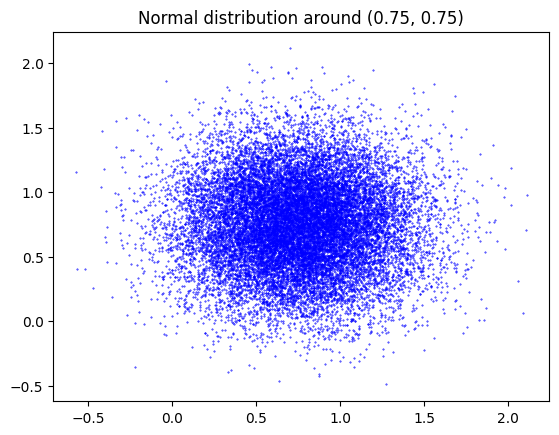

In [2]:
points = np.random.multivariate_normal(mean=np.array([0.75,0.75]),
                                   cov=np.array([[0.12,0],[0,0.12]]),
                                  size=20000)

print(points.shape)

plt.plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
plt.title('Normal distribution around (0.75, 0.75)')
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/dn/583y80ks1x9c_5n961lfvw840000gn/T/ipykernel_49536/2430150711.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Wrapped points in [0, $\pi$] x [0, $2\pi$]')


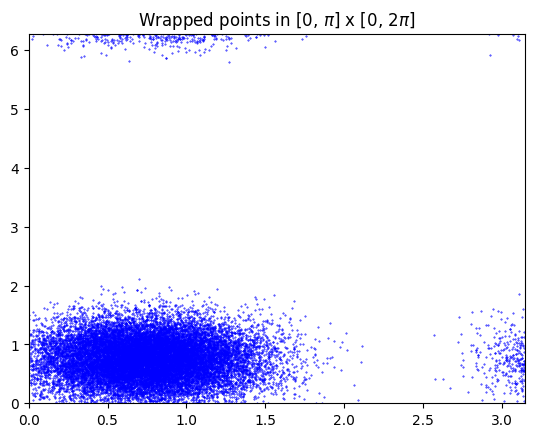

In [3]:
wrapped_points = points % 2 - 1  # Wrap points to [-1, 1] x [-1, 1]

u,v = points[:,0], points[:,1]

wrapped_u = u % np.pi
wrapped_v = v % (2 * np.pi)
wrapped_points = np.stack([wrapped_u, wrapped_v], axis=1)

plt.plot(wrapped_points[:,0], wrapped_points[:,1], 'o', markersize=0.4, color='blue')
plt.xlim(0, np.pi)
plt.ylim(0, 2 * np.pi)
plt.title('Wrapped points in [0, $\pi$] x [0, $2\pi$]')
plt.show()

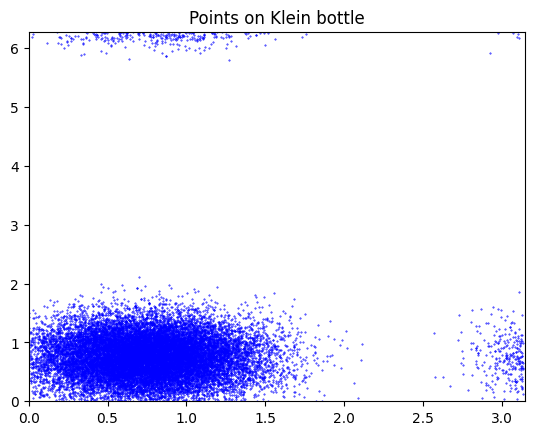

In [4]:
u, v = wrapped_points[:,0], wrapped_points[:,1]
mask_u = u >= np.pi - 1e-2
mask_v = v >= 2 * np.pi - 1e-2

u_klein = np.where(mask_u,-u, u)
v_klein = np.where(mask_v, 1 - v, v)
klein_points = np.stack([u_klein, v_klein], axis=1)

plt.plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
plt.xlim(0, np.pi)
plt.ylim(0, 2 * np.pi)
plt.title('Points on Klein bottle')
plt.show()

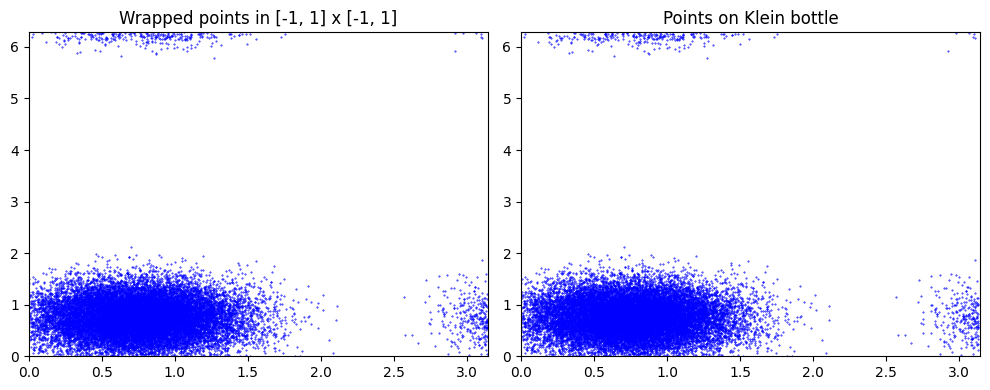

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(wrapped_points[:,0], wrapped_points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title('Wrapped points in [-1, 1] x [-1, 1]')
axes[0].set_xlim(0, np.pi)
axes[0].set_ylim(0, 2 * np.pi)

axes[1].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Klein bottle')
axes[1].set_xlim(0, np.pi)
axes[1].set_ylim(0, 2 * np.pi)

plt.tight_layout()
plt.show()

Functions

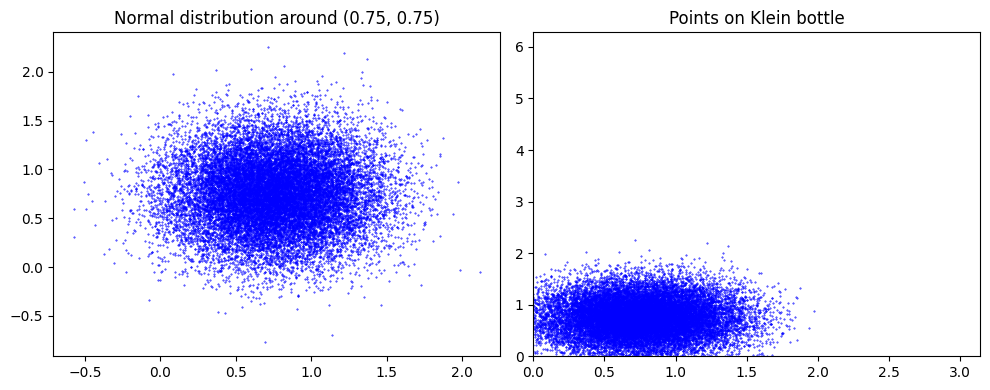

In [6]:
def projection_on_klein(u, v, eps=1e-5) -> np.ndarray:
    wrapped_u = u % np.pi
    wrapped_v = v % (2 * np.pi)
    mask_u = u >= np.pi - eps
    mask_v = v >= 2 * np.pi - eps
    u_klein = np.where(mask_u,-u, u)
    v_klein = np.where(mask_v, 2 * np.pi - v, v)
    return np.stack([u_klein, v_klein], axis=1)


points = np.random.multivariate_normal(mean=np.array([0.75, 0.75]),
                                       cov=np.array([[0.12, 0], [0, 0.12]]),
                                       size=20000)
klein_points = projection_on_klein(points[:,0], points[:,1])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title('Normal distribution around (0.75, 0.75)')

axes[1].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Klein bottle')
axes[1].set_xlim(0, np.pi)
axes[1].set_ylim(0, 2 * np.pi)

plt.tight_layout()
plt.show()

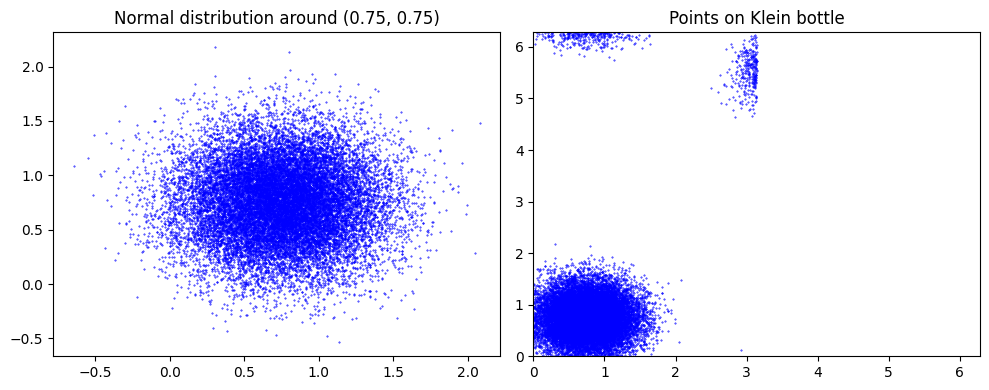

In [34]:
def project_klein(theta1, theta2, eps=1e-3):
    """
    Project any (theta1, theta2) in R^2 onto the canonical
    fundamental domain D = [0, 2π) × [0, π) for the Klein bottle, using:

        1) (θ1, θ2) ~ (θ1 + 2π k,    θ2 + 2π ℓ)     for k,ℓ ∈ Z
        2) (θ1, θ2) ~ (θ1 + π,      -θ2)            (the flip relation)

    Steps:
      a) Reduce θ1 mod 2π  → u ∈ [0, 2π)
      b) Reduce θ2 mod 2π  → v ∈ [0, 2π)
      c) If v < π, keep (φ2 = v,   φ1 = u).
         Else (π ≤ v < 2π), fold v → φ2 = 2π - v ∈ [0, π),
                              shift u → φ1 = (u + π) mod 2π.
    Returns (φ1, φ2) with φ1 ∈ [0, 2π), φ2 ∈ [0, π).
    """

    # 1) Reduce each coordinate to [0, 2π)
    u = np.remainder(theta1, 2 * np.pi)
    v = np.remainder(theta2, 2 * np.pi)
    
    #corner_mask = (u >= 2 * np.pi - eps) | (v >= 2 * np.pi - eps)
    #u[corner_mask], v[corner_mask] = 2 * np.pi - u[corner_mask], 2 * np.pi - v[corner_mask]

    u_mask = (u >= np.pi)
    u[u_mask] = u[u_mask] - np.pi
    v[u_mask] = np.remainder(- v[u_mask], 2 * np.pi) #2 * np.pi - v[u_mask] #np.remainder(- v[u_mask], 2 * np.pi)
    
    return np.stack([u, v], axis=1)    

# Example usage
points = np.random.multivariate_normal(mean=np.array([0.75, 0.75]),
                                       cov=np.array([[0.12, 0], [0, 0.12]]),
                                       size=20000)
klein_points = project_klein(points[:,0], points[:,1])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title('Normal distribution around (0.75, 0.75)')
axes[1].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Klein bottle')
axes[1].set_xlim(0, 2 * np.pi)
axes[1].set_ylim(0, 2 * np.pi)
plt.tight_layout()
plt.show()

19698 points in bottom half
302 points in top half


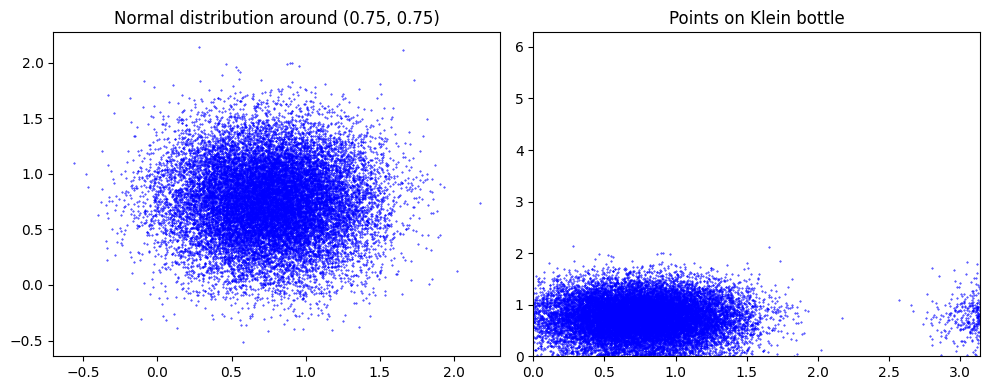

In [22]:
def project_to_klein(u, v, eps=1e-3):
    """
    Given any real u, v (as scalars or arrays), return (u_k, v_k) ∈ [0, π)×[0, 2π)
    that represent the same point on the Klein bottle under the identifications:

      1) (u, v) ~ (u mod π, v)         [period π in u]
      2) (u, v) ~ (u, v mod 2π)        [period 2π in v]
      3) (u,  0) ~ (u + π,  2π)        [“bottom‐edge” glued to top, with u→u+π]
         i.e. whenever v_mod ≥ π we do:
            u_k = (u_mod + π) mod π,
            v_k = 2π − v_mod.

    After these steps:
      • u_k ∈ [0, π),
      • v_k ∈ [0, 2π),
    and the Klein‐flip(“half‐period in u + reflection in v”) is accounted for.
    """

    # 1) Periodic wrap into the torus‐cover rectangle:
    #    u_mod ∈ [0, π),  v_mod ∈ [0, 2π).
    u_mod = np.remainder(u, np.pi)         # in [0, π)
    v_mod = np.remainder(v, 2 * np.pi)     # in [0, 2π)

    # 2) Allocate output arrays of the same shape:
    u_k = np.empty_like(u_mod, dtype=float)
    v_k = np.empty_like(v_mod, dtype=float)

    # 3) Decide where v_mod lies:
    mask_bottom = (v_mod < np.pi - eps)  # “Bottom half” of [0, 2π)
    mask_top    = (v_mod >= np.pi - eps) # “Top half”  of [0, 2π)

    print((mask_bottom == True).sum(), "points in bottom half")
    print((mask_top == True).sum(), "points in top half")

    # Case A: v_mod < π → no flip in u, just pass through
    if np.any(mask_bottom):
        u_k[mask_bottom] = u_mod[mask_bottom]
        v_k[mask_bottom] = v_mod[mask_bottom]

    # Case B: v_mod ≥ π → flip:  (u, v) → (u+π,  2π - v)  (then reduce mod π or 2π as needed)
    #    - (u_mod + π) mod π  is the same as  (u_mod + π) - π  if u_mod < π, i.e. = u_mod.
    #      But in the rare case u_mod is exactly 0 (or extremely close to 0), adding π → π; mod π → 0.
    #      So strictly we do np.remainder(u_mod + π, π).
    #    - v_k = 2π - v_mod, which lands in [0, π).
    if np.any(mask_top):
        u_k[mask_top] = np.remainder(u_mod[mask_top] + np.pi, np.pi)
        v_k[mask_top] = 2 * np.pi - v_mod[mask_top]

    return u_k, v_k

# Example usage:
points = np.random.multivariate_normal(mean=np.array([0.75, 0.75]),
                                       cov=np.array([[0.12, 0], [0, 0.12]]),
                                       size=20000)
us, vs = project_to_klein(points[:,0], points[:,1])
klein_points = np.stack([us, vs], axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(points[:,0], points[:,1], 'o', markersize=0.4, color='blue')
axes[0].set_title('Normal distribution around (0.75, 0.75)')
axes[1].plot(klein_points[:,0], klein_points[:,1], 'o', markersize=0.4, color='blue')
axes[1].set_title('Points on Klein bottle')
axes[1].set_xlim(0, np.pi)
axes[1].set_ylim(0, 2 * np.pi)
plt.tight_layout()
plt.show()

In [35]:
from typing import Callable

def projection_onto_a_line(theta: float) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Creates a function that projects a point onto a line.
    """
    return lambda x,y: (x * np.cos(theta) + y * np.sin(theta))
    

def chebyshev_2(t: float) -> float:
    """
    Chebyshev polynomial of the 2nd degree.
    """
    return 2 * t**2 - 1


def klein_filter(theta_1: float, theta_2: float) -> Callable[[np.ndarray, np.ndarray], float]:
    """
    Klein filter for given angles theta_1 and theta_2.
    """
    t = projection_onto_a_line(theta_1)
    return lambda x,y: np.sin(theta_2) * t(x,y) + np.cos(theta_2) * chebyshev_2(t(x,y))

def generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True) -> np.ndarray:
    """
    Generate a Klein filter matrix of given size for specified angles.

    Parameters:
    - theta_1: Angle for the first projection.
    - theta_2: Angle for the second projection.
    - size: Size of the matrix.
    - midpoint: If True, use midpoints for the grid; otherwise, use edges.
    """
    f = klein_filter(theta_1, theta_2)
    coords = np.linspace(-1 + 1/size, 1 - 1/size, size) if midpoint else np.linspace(-1, 1, size)
    X, Y = np.meshgrid(coords, coords)
    Z = f(X, Y)
    return Z

thetas_1: [0.         0.31415927 0.62831853 0.9424778  1.25663706 1.57079633
 1.88495559 2.19911486 2.51327412 2.82743339 3.14159265]
thetas_2: [0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
 3.76991118 4.39822972 5.02654825 5.65486678 6.28318531]
thetas_1: [0.         0.31415927 0.62831853 0.9424778  1.25663706 1.57079633
 1.88495559 2.19911486 2.51327412 2.82743339 0.        ]
thetas_2: [0.         0.62831853 1.25663706 1.88495559 2.51327412 3.14159265
 3.76991118 4.39822972 5.02654825 5.65486678 0.        ]


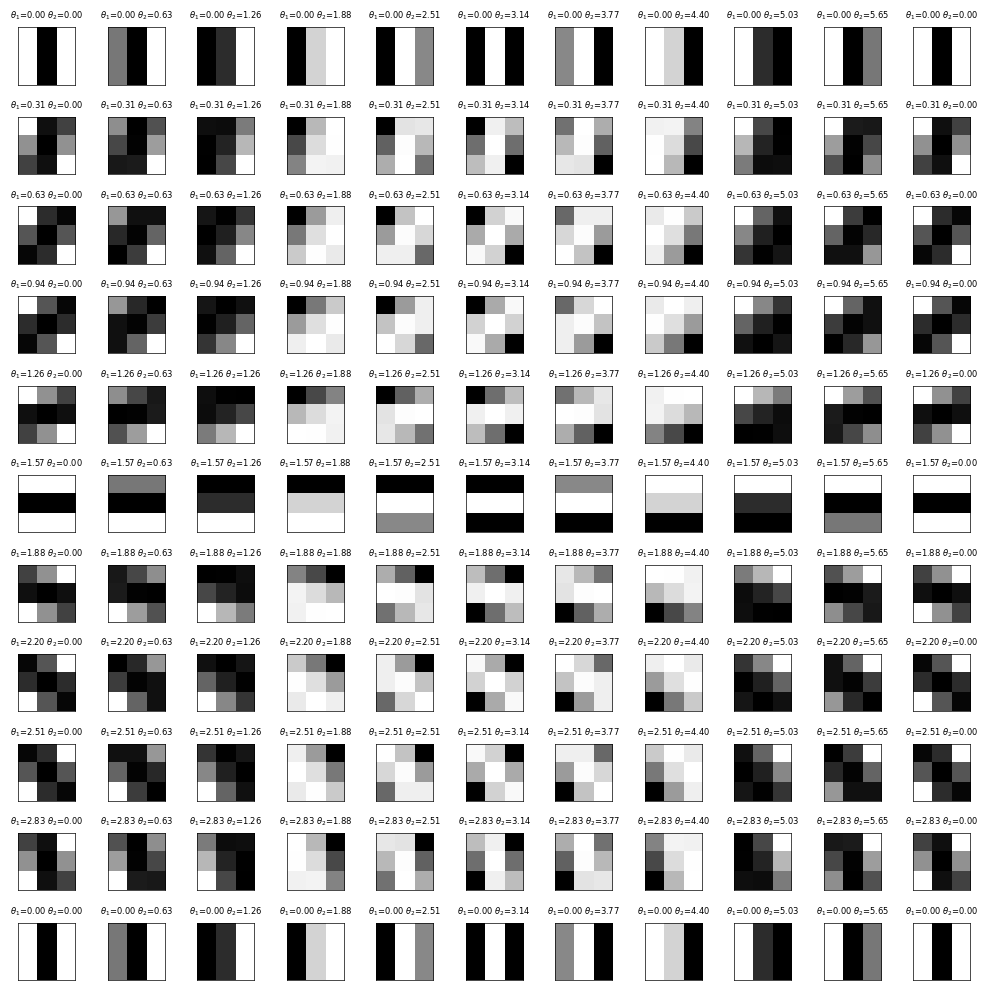

In [32]:
n = 10
thetas_1 = np.linspace(0, np.pi, n+1)
thetas_2 = np.linspace(0, 2 * np.pi, n+1)
print(f"thetas_1: {thetas_1}")
print(f"thetas_2: {thetas_2}")
points_on_klein = project_klein(thetas_1, thetas_2)
thetas_1 = points_on_klein[:, 0]
thetas_2 = points_on_klein[:, 1]
print(f"thetas_1: {thetas_1}")
print(f"thetas_2: {thetas_2}")


fig, axes = plt.subplots(n+1, n+1, figsize=(10, 10))
for i in range(0, n+1):
    for j in range(0, n+1):
        # Use projection_on_klein to get (theta_1, theta_2)
        theta_1 = thetas_1[i]
        theta_2 = thetas_2[j]
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        axes[i, j].imshow(filter_img, cmap='gray', extent=[-1, 1, -1, 1])
        axes[i, j].set_title(f"$\\theta_1$={theta_1:.2f}\t$\\theta_2$={theta_2:.2f}", fontsize=6)
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()


log_prob: -0.32985062892857675
prob: 0.7190311278608713


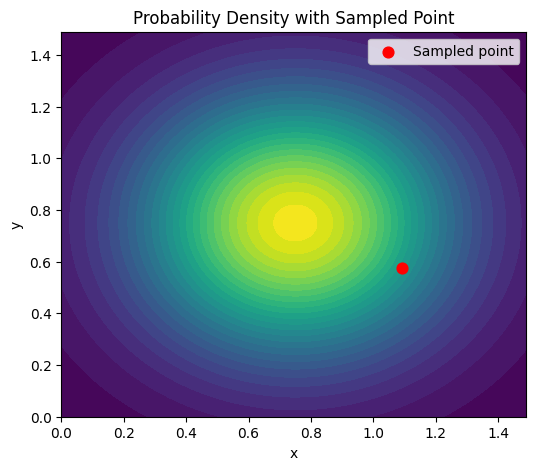

In [55]:
from scipy.stats import multivariate_normal

point = np.random.multivariate_normal(mean=np.array([0.75, 0.75]),
                                       cov=np.array([[0.12, 0], [0, 0.12]]),
                                       size=1)

mean = np.array([0.75, 0.75])
cov = np.array([[0.12, 0], [0, 0.12]])
log_prob = multivariate_normal(mean=mean, cov=cov).logpdf(point[0])
print("log_prob:", log_prob)
print("prob:", np.exp(log_prob))

x, y = np.mgrid[0:1.5:0.01, 0:1.5:0.01]
pos = np.dstack((x, y))
rv = multivariate_normal(mean, cov)
plt.figure(figsize=(6, 5))
plt.contourf(x, y, rv.pdf(pos), levels=30, cmap='viridis')
plt.scatter(point[0, 0], point[0, 1], color='red', s=60, label='Sampled point')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Probability Density with Sampled Point')
plt.legend()
plt.show()